# NB04 – Visualisierungen

**Grid-Arbitrage** · Batteriespeicher-Arbitrage im Schweizer Strommarkt

**Gruppe:** SC26_Gruppe_2 | **Verantwortlich:** Cyril Saladin | **Datum:** März 2026

---

*Erstellt die Pflicht-Charts 1–5 aus berechneten Zwischenergebnissen.*


| [← NB03 Daten Analyse](03_Daten_Analyse.ipynb) | [↑ Übersicht ↑](../organisation/O_01_Project_Overview.ipynb) | [NB00 Business Case →](00_Business_Case.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_NB_04'></a>

[Einleitung](#einleitung_NB_04)  
[Initialisierung](#initialisierung_NB_04)  
1 [Summary-Diagramm – Wirtschaftlichkeit](#chart-1-aufgabe-a-summary-diagramm-wirtschaftlichkeit_NB_04)  
2 [Heatmap – Spot-Preis Stunde × Monat](#chart-2-aufgabe-b-heatmap-spot-preis-nach-stunde-monat_NB_04)  
3 [Tagesprofil Netzlast & Spot-Preis](#chart-3-tagesprofil-netzlast-spot-preis_NB_04)  
4 [Netzentlastungsszenarien](#chart-4-netzentlastungsszenarien_NB_04)  
5 [Saisonale Arbitrage-Analyse](#saisonale-arbitrage-analyse_NB_04)  
[Fazit](#fazit_NB_04)  
[Abschluss](#abschluss_NB_04)  


---
## Einleitung <a id='einleitung_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Aggregation der Pflicht-Charts aus den NB03-Outputs:

1. **Summary-Diagramm** (Pflichtaufgabe a) — 4-Panel-Wirtschaftlichkeit
2. **Heatmap Stunde × Monat** (Pflichtaufgabe b) — Spot-Preis-Muster
3. **Tagesprofil** — Netzlast und Spot-Preis im Durchschnittstag
4. **Netzentlastungsszenarien** — Rollout-Effekt auf Spitzenlast
5. **Saisonale Arbitrage-Analyse** — Frühling/Sommer/Winter im Vergleich

Alle Charts werden sowohl als Panel- als auch als Einzelplot-Version
erzeugt (Einzelplots für Bericht-Einbettung in Business Case NB00 und K-Notebooks).
Farben und Styles kommen einheitlich aus `../sync/config.json`.


## Initialisierung<a id='initialisierung_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Lädt `../sync/config.json`, setzt Verzeichnispfade und Farbpalette, liest alle vier Eingabe-DataFrames aus `../data/processed/` und `../data/intermediate/`.

**Setup – Imports & Konfiguration:** Bibliotheken laden, `../sync/config.json` lesen,
Farbpalette und Pfade setzen, alle vier Eingabe-DataFrames einlesen.


In [1]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
# Notebook liegt in einem Unterordner (kuer/, experimental/, notebooks/,
# organisation/). Damit 'from lib.xxx import ...' funktioniert, muss der
# Projekt-Root vorne in sys.path stehen. autoreload sorgt dafür, dass
# Änderungen in lib/*.py ohne Kernel-Restart übernommen werden.
import sys, os
_PROJECT_ROOT = os.path.abspath('..')
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

# lib-Imports (einmal zentral — in allen folgenden Zellen verfügbar)
from lib.plotting import show_source
from lib.io_ops   import load_transfer, final_check

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')

lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [2]:
import os, sys, warnings, json
import numpy  as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import matplotlib.patches   as mpatches
from   matplotlib.colors    import Normalize
from   matplotlib           import cm
from datetime import datetime
warnings.filterwarnings('ignore')

# Versionen anzeigen für Reproduzierbarkeit
print(f"Matplotlib   Version: {mpl.__version__}")
print(f"Numpy        Version: {np.__version__}")
print(f"Pandas       Version: {pd.__version__}")
print(f"\U0001f4c5 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")

Matplotlib   Version: 3.10.8
Numpy        Version: 2.2.6
Pandas       Version: 2.3.3
📅 Zuletzt ausgeführt am: 26.04.2026 um 21:29:12


In [3]:
# ── ../sync/config.json laden ───────────────────────────────────────────────────────
# Schalter NIE direkt hier setzen — immer in ../sync/config.json anpassen.
import json
with open('../sync/config.json') as _f: CFG = json.load(_f)

# transfer.json laden (SSOT für Saisonal-Kennzahlen aus NB03)
TF          = load_transfer()
TF_SAISONAL = TF.get('simulation', {}).get('saisonal', {})

# Aliases (nur lesend)
MODE          = CFG['mode']
FORCE_RELOAD  = CFG['force_reload']  # gelesen, in NB03 passiv
LIFETIME      = CFG['pflicht']['wirtschaftlichkeit']['lifetime_j']
ZIEL_ROI      = round(100 / LIFETIME, 2)  # 1/lifetime_j
LIFETIME_LONG = CFG['pflicht']['langzeit']['lifetime_long_j']
_sim_disp  = CFG['pflicht']['simulation']
CHARGE_Q   = _sim_disp['charge_quantile']   # 0.25 — aus ../sync/config.json (SSOT)
DISCHARGE_Q= _sim_disp['discharge_quantile'] # 0.75 — aus ../sync/config.json (SSOT)
SYMLOG_THRESH = CFG['visualisierung']['symlog_linthresh']
BASE_PEAK_GW  = CFG['szenarien']['ch_spitzenlast_gw']
print(f'../sync/config.json | MODE={MODE} | LIFETIME={LIFETIME} Jahre | SYMLOG={SYMLOG_THRESH}')
DIR_RAW    = os.path.join('../data', 'raw')           # ch_netzlast_raw.csv (Roh, von NB1)
DIR_PROC   = os.path.join('../data', 'processed')     # ch_spot_prices_clean.csv (von NB2)
DIR_INTER    = os.path.join('../data', 'intermediate')        # szenario-unabhängig (spread etc.)
SZ_AKTIV     = CFG['szenarien']['gleichzeitigkeit_aktiv']
DIR_INTER_SZ = os.path.join(DIR_INTER, SZ_AKTIV)          # wirtschaftlichkeit.csv, szenarien.csv
CHARTS_DIR = os.path.join('../output', 'charts', SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)
DPI = CFG['visualisierung']['output_dpi']  # SSOT: ../sync/config.json

# Farbpalette aus ../sync/config.json (SSOT)
_viz       = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK    = _viz.get('bg_dark',    '#0d1117')
BG_PANEL   = _viz.get('bg_panel',   '#141414')
C_PRICE    = _viz.get('c_price',    '#FFA726')
C_LOAD     = _viz.get('c_load',     '#66BB6A')
C_CHARGE   = _viz.get('c_charge',   '#1565C0')
C_FEED     = _viz.get('c_feed',     '#B71C1C')
SEG_COLORS = _viz.get('seg_colors', ['#42A5F5','#66BB6A','#FFA726','#EF5350'])
C_PRIV, C_GEW, C_IND, C_UTIL = SEG_COLORS  # Aliases
C_SPINE     = _viz.get('c_spine',     '#333333')  # Achsenrahmen
C_ACHSE     = _viz.get('c_achse',     '#aaaaaa')  # Achsenbeschriftungen
C_TICK      = _viz.get('c_tick',      '#bbbbbb')  # Tick-Labels
C_LEGENDE_BG= _viz.get('c_legende_bg','#111111')  # Legenden-Hintergrund
C_GITTER    = _viz.get('c_gitter',    '#cccccc')  # Gitterlinien
C_SOLAR     = _viz.get('c_solar',     '#FDD835')  # Solar-Ertrag
C_GRENZWERT = _viz.get('c_amber_dark','#FF6F00')  # Grenzwert / Warnung
C_GRUEN_DARK= _viz.get('c_gruen_dark','#388E3C')  # Erneuerbare
C_DISPATCH  = _viz.get('c_dispatch',  '#AB47BC')  # Dispatch-optimal
C_STACKING  = _viz.get('c_stacking',  '#5DCAA5')  # Revenue Stacking
C_CYAN      = _viz.get('c_cyan',      '#26C6DA')  # Alt. Speicher
C_GRID    = _viz.get('c_grid',    '#888888')  # Gitter / Annotationslinien
C_NO_DISP      = _viz.get('c_no_disp',     '#9E9E9E')   # Kein-Dispatch-Segment
# SAISON_COLORS: config-Werte überschreiben Defaults — funktioniert auch ohne et_colors in config
_sc_def = {'Winter': C_PRIV, 'Frühling': C_GEW, 'Sommer': C_SOLAR, 'Herbst': C_GRENZWERT}
SAISON_COLORS  = {**_sc_def, **_viz.get('saison_colors', {})}  # SSOT: config.json → visualisierung.farben.saison_colors

# Daten laden
df_prices = pd.read_csv(os.path.join(DIR_PROC,  'ch_spot_prices_clean.csv'),
                        parse_dates=['timestamp'])
df_econ   = pd.read_csv(os.path.join(DIR_INTER_SZ, 'wirtschaftlichkeit.csv'))
df_sc     = pd.read_csv(os.path.join(DIR_INTER_SZ, 'netzentlastung_szenarien.csv'))
df_load   = pd.read_csv(os.path.join(DIR_RAW,   'ch_netzlast_raw.csv'),
                        parse_dates=['timestamp'])

# ── FIX 2: Spalten-Aliases (NB2 speichert 'roi_pct', Chart 1 erwartet 'roi') ─
if 'roi_pct'       in df_econ.columns and 'roi'     not in df_econ.columns:
    df_econ['roi']     = df_econ['roi_pct']
if 'payback_years'  in df_econ.columns and 'payback' not in df_econ.columns:
    df_econ['payback'] = df_econ['payback_years']

# ── FIX 3: Zeitfeatures sicherstellen (.dt.hour statt .hour auf Series) ──────
df_prices['timestamp'] = pd.to_datetime(df_prices['timestamp'], utc=True)
if 'hour'  not in df_prices.columns:
    df_prices['hour']  = df_prices['timestamp'].dt.hour
if 'month' not in df_prices.columns:
    df_prices['month'] = df_prices['timestamp'].dt.month
df_load['timestamp'] = pd.to_datetime(df_load['timestamp'], utc=True)

print(f'MODE       : {MODE}')
print(f'df_prices  : {len(df_prices):,} Zeilen  <- {DIR_PROC}/ch_spot_prices_clean.csv')
print(f'df_load    : {len(df_load):,} Zeilen  <- {DIR_RAW}/ch_netzlast_raw.csv')
print(f'df_econ    : {len(df_econ)} Segmente <- {DIR_INTER_SZ}/wirtschaftlichkeit.csv')
print(f'df_sc      : {len(df_sc)} Szenarien <- {DIR_INTER_SZ}/netzentlastung_szenarien.csv')
print(f'df_econ Spalten: {list(df_econ.columns)}')
print('Daten geladen. Erstelle Visualisierungen...')

../sync/config.json | MODE=data | LIFETIME=12 Jahre | SYMLOG=10000
MODE       : data
df_prices  : 29,087 Zeilen  <- ../data\processed/ch_spot_prices_clean.csv
df_load    : 29,070 Zeilen  <- ../data\raw/ch_netzlast_raw.csv
df_econ    : 4 Segmente <- ../data\intermediate\realistisch/wirtschaftlichkeit.csv
df_sc      : 4 Szenarien <- ../data\intermediate\realistisch/netzentlastung_szenarien.csv
df_econ Spalten: ['segment', 'capex', 'annual_rev', 'opex_annual', 'net_annual', 'payback_years', 'roi_pct', 'rev_per_kwh', 'roi', 'payback']
Daten geladen. Erstelle Visualisierungen...


In [4]:
# ── ⚙ Markdown-Prüfwerte ──────────────────────────────────────────────────────
# Diese Werte erscheinen als ⚙ im Markdown-Text.
# Nach jeder config-Änderung: Ausgabe mit ⚙-Stellen im Text vergleichen!
_s  = CFG['pflicht']['simulation']
_w  = CFG['pflicht']['wirtschaftlichkeit']
print('=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===')
print(f'  ZIEL_ROI     = {ZIEL_ROI}%  (= 100 / {LIFETIME} Jahre)')
print(f'  LIFETIME     = {LIFETIME} Jahre  |  LIFETIME_LONG = {LIFETIME_LONG} Jahre')
print(f'  EFFICIENCY   = {_s["efficiency_roundtrip"]*100:.0f}%')
print(f'  SOC          = {_s["soc_min_pct"]*100:.0f}%–{_s["soc_max_pct"]*100:.0f}%')
print(f'  OPEX_RATE    = {_w["opex_rate"]*100:.1f}%')


=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===
  ZIEL_ROI     = 8.33%  (= 100 / 12 Jahre)
  LIFETIME     = 12 Jahre  |  LIFETIME_LONG = 20 Jahre
  EFFICIENCY   = 92%
  SOC          = 5%–95%
  OPEX_RATE    = 1.5%


**Verifikation Setup:** Alle vier Eingabe-DataFrames auf Shape und Spalten prüfen,
bevor die Chart-Erzeugung beginnt.

In [5]:
# ── Verifikation: Eingabedaten ───────────────────────────────────────────────
print(f'Preise  : {df_prices.shape} | Last: {df_load.shape}')
print(f'Econ    : {df_econ.shape}   | Szenarien: {df_sc.shape}')
df_econ[['segment','capex','roi_pct','payback_years']].head()


Preise  : (29087, 6) | Last: (29070, 2)
Econ    : (4, 10)   | Szenarien: (4, 9)


,segment,capex,roi_pct,payback_years
0,Privat_10kWh,4000,1.797746,55.625218
1,Gewerbe_100kWh,30000,3.142066,31.826197
2,Industrie_1MWh,220000,4.578246,21.842428
3,Utility_10MWh,1800000,2.972600,33.640583


**Setup.** `DIR_PROC` = `processed/` (Zeitreihen), `DIR_INTER` = `intermediate/` (Simulationsergebnisse), `DIR_RAW` = `raw/` (Netzlast-Rohdaten).
Spalten-Aliases (`roi_pct→roi`, `payback_years→payback`) stellen Kompatibilität unabhängig vom Datenherkunft-Modus sicher.

---
## 1. Summary-Diagramm – Wirtschaftlichkeit <a id='chart-1-aufgabe-a-summary-diagramm-wirtschaftlichkeit_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

*Fasst die Ergebnisse der Analyse zusammen und weckt das Interesse des Publikums.*


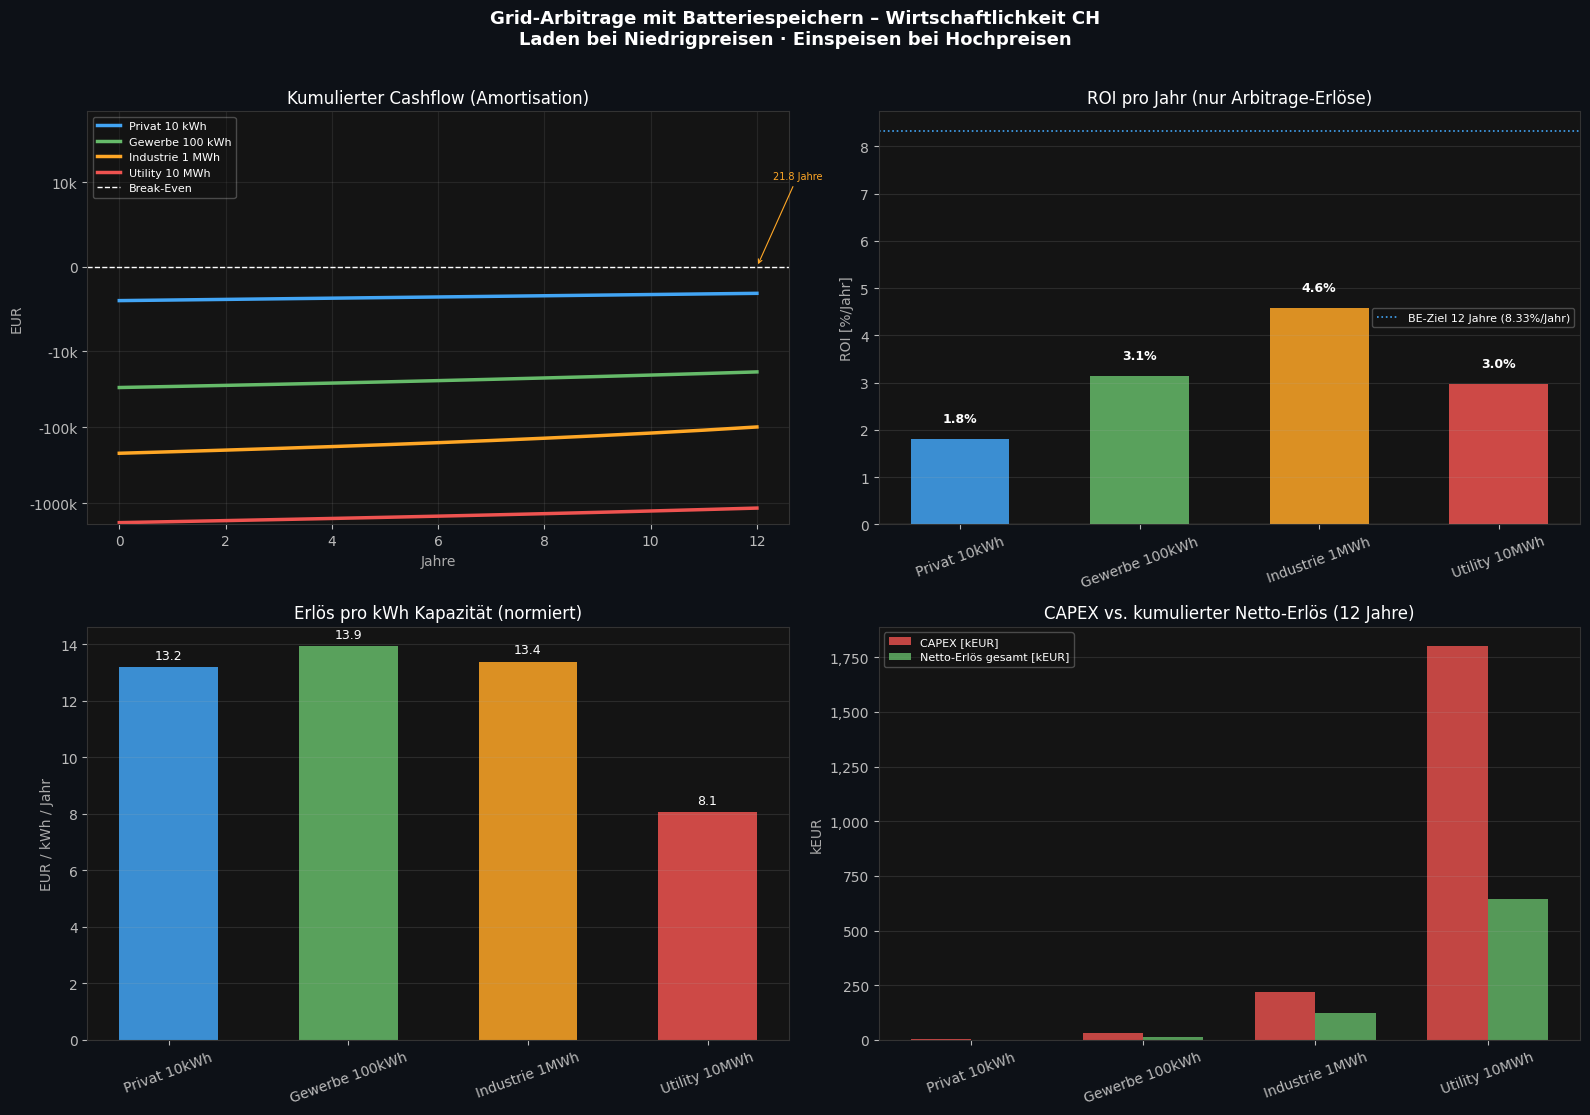

✅ Chart 1 gespeichert: ../output\charts\realistisch\nb04_wirtschaftlichkeit.png


In [6]:
# ── Chart 1: Wirtschaftlichkeit-Summary (4 Panels) ──────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(BG_DARK)
for ax in axes.flat:
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors='#bbbbbb')
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)

fig.suptitle('Grid-Arbitrage mit Batteriespeichern – Wirtschaftlichkeit CH\n'
             'Laden bei Niedrigpreisen · Einspeisen bei Hochpreisen',
             color='white', fontsize=13, fontweight='bold', y=1.01)

seg_names = df_econ['segment'].str.replace('_', ' ').tolist()

# --- Panel 1: Kumulierter Cashflow (Amortisationskurven) ---
ax = axes[0, 0]
years = np.arange(0, LIFETIME + 1)
for (segment, capex, net_annual), color in zip(
        zip(df_econ['segment'], df_econ['capex'], df_econ['net_annual']), SEG_COLORS):
    cf  = -capex + net_annual * years   # NumPy vector — keine List-Comprehension
    lbl = segment.replace('_',' ').replace('kWh',' kWh').replace('MWh',' MWh')
    ax.plot(years, cf, color=color, lw=2.5, label=lbl)
    if net_annual > 0:
        be_yr = capex / net_annual
        if be_yr <= 30:
            ax.annotate(f'{be_yr:.1f} Jahre',
                        xy=(min(be_yr, LIFETIME), 0),
                        xytext=(min(be_yr, LIFETIME) + 0.3, capex * 0.05),
                        color=color, fontsize=7,
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.8))
ax.axhline(0, color='white', lw=1, linestyle='--', label='Break-Even')
ax.set_title('Kumulierter Cashflow (Amortisation)', color='white')
ax.set_xlabel('Jahre', color='#aaaaaa')
ax.set_ylabel('EUR', color='#aaaaaa')
# Symlog: alle Segmente sichtbar trotz 100x CAPEX-Unterschied
ax.set_yscale('symlog', linthresh=SYMLOG_THRESH)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v/1000:.0f}k' if abs(v) >= 1000 else f'{v:.0f}'))
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, alpha=0.12)

# --- Panel 2: ROI pro Jahr Vergleich ---
ax = axes[0, 1]
roi_vals = df_econ['roi'].values
bars = ax.bar(seg_names, roi_vals, color=SEG_COLORS, alpha=0.85, width=0.55)
ax.axhline(0, color='white', lw=0.8)
ax.axhline(ZIEL_ROI, color='#42A5F5', lw=1.2, linestyle=':',
               label=f'BE-Ziel {LIFETIME} Jahre ({ZIEL_ROI}%/Jahr)')
for bar, val in zip(bars, roi_vals):
    ypos = val + 0.3 if val >= 0 else val - 0.8
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.1f}%',
            ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax.set_title('ROI pro Jahr (nur Arbitrage-Erlöse)', color='white')
ax.set_ylabel('ROI [%/Jahr]', color='#aaaaaa')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

# --- Panel 3: Erlös pro kWh normiert ---
ax = axes[1, 0]
rev_kwh = df_econ['rev_per_kwh'].values
bars2 = ax.bar(seg_names, rev_kwh, color=SEG_COLORS, alpha=0.85, width=0.55)
for bar, val in zip(bars2, rev_kwh):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', va='bottom', color='white', fontsize=9)
ax.set_title('Erlös pro kWh Kapazität (normiert)', color='white')
ax.set_ylabel('EUR / kWh / Jahr', color='#aaaaaa')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, axis='y', alpha=0.15)

# --- Panel 4: CAPEX vs. kumulierter Netto-Erlös ---
ax = axes[1, 1]
x = np.arange(len(seg_names))
w = 0.35
capex_vals  = df_econ['capex'].values / 1000  # → kEUR
net_total   = (df_econ['net_annual'] * LIFETIME).values / 1000
ax.bar(x - w/2, capex_vals,  w, label='CAPEX [kEUR]',    color='#EF5350', alpha=0.8)
ax.bar(x + w/2, net_total,   w, label='Netto-Erlös gesamt [kEUR]', color='#66BB6A', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(seg_names, rotation=20)
ax.set_title(f'CAPEX vs. kumulierter Netto-Erlös ({LIFETIME} Jahre)', color='white')
ax.set_ylabel('kEUR', color='#aaaaaa')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
chart1_path = os.path.join(CHARTS_DIR, 'nb04_wirtschaftlichkeit.png')
plt.savefig(chart1_path, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'✅ Chart 1 gespeichert: {chart1_path}')

**Einzelplots** (für Bericht-Einbettung):

In [7]:
# ── Chart 1: Einzelplots ─────────────────────────────────────────────────────
# Jedes der 4 Panels als eigenständiges Bild (grösser, für Bericht)
PANEL_DEFS = [
    ('nb04_amortisation.png',     'Kumulierter Cashflow (Amortisation)',
     'Zeitraum [Jahre]', 'EUR'),
    ('nb04_roi.png',              'ROI pro Jahr (nur Arbitrage-Erlöse)',
     'Segment', 'ROI [%/Jahr]'),
    ('nb04_erloese_kwh.png',      'Erlös pro kWh Kapazität (normiert)',
     'Segment', 'EUR / kWh / Jahr'),
    ('nb04_capex_ertrag.png',     f'CAPEX vs. kumulierter Netto-Erlös ({LIFETIME} Jahre)',
     'Segment', 'kEUR'),
]

for (filename, title, xlabel, ylabel), ax_src in zip(PANEL_DEFS, axes.flat):
    fig_s, ax_s = plt.subplots(figsize=(10, 6))
    fig_s.patch.set_facecolor(BG_DARK)
    ax_s.set_facecolor(BG_PANEL)
    ax_s.tick_params(colors='#bbbbbb')
    for sp in ax_s.spines.values(): sp.set_edgecolor(C_SPINE)

    # Inhalte neu zeichnen (aus df_econ — gleiche Daten wie Komposit)
    if 'Amortisation' in title:
        years_x = np.arange(0, LIFETIME + 1)
        for (segment, capex, net_annual), color in zip(
                zip(df_econ['segment'], df_econ['capex'], df_econ['net_annual']), SEG_COLORS):
            cf  = -capex + net_annual * years_x   # NumPy vector
            lbl = segment.replace('_',' ').replace('kWh',' kWh').replace('MWh',' MWh')
            ax_s.plot(years_x, cf, color=color, lw=2.5, label=lbl)
            if net_annual > 0:
                be = capex / net_annual
                if be <= LIFETIME + 5:
                    ax_s.annotate(f'{be:.1f} Jahre', xy=(min(be, LIFETIME), 0),
                        xytext=(min(be, LIFETIME)+0.3, capex*0.05),
                        color=color, fontsize=8,
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.8))
        ax_s.axhline(0, color='white', lw=1, linestyle='--', label='Break-Even')
        # Symlog: alle Segmente sichtbar trotz 100x CAPEX-Unterschied
        ax_s.set_yscale('symlog', linthresh=SYMLOG_THRESH)
        ax_s.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v,_: f'{v/1000:.0f}k' if abs(v) >= 1000 else f'{v:.0f}'))
        ax_s.set_xlabel('Jahre', color='#aaa')

    elif 'ROI' in title:
        roi_vals = df_econ['roi_pct'].values
        bars = ax_s.bar(seg_names, roi_vals, color=SEG_COLORS, alpha=0.85)
        ax_s.axhline(ZIEL_ROI, color='#42A5F5', lw=1.5, linestyle=':',
                       label=f'BE-Ziel {LIFETIME} Jahre ({ZIEL_ROI}%/Jahr)')
        for bar, val in zip(bars, roi_vals):
            ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                      f'{val:.1f}%', ha='center', color='white', fontsize=10, fontweight='bold')
        ax_s.set_ylabel('ROI [%/Jahr]', color='#aaa')

    elif title.startswith('Erlös'):
        rev_vals = df_econ['rev_per_kwh'].values
        bars = ax_s.bar(seg_names, rev_vals, color=SEG_COLORS, alpha=0.85)
        for bar, val in zip(bars, rev_vals):
            ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                      f'{val:.1f}', ha='center', color='white', fontsize=10)
        ax_s.set_ylabel('EUR / kWh / Jahr', color='#aaa')

    else:  # CAPEX vs Ertrag
        x = np.arange(len(seg_names)); w = 0.35
        capex_v = df_econ['capex'].values / 1000
        net_v   = (df_econ['net_annual'] * LIFETIME).values / 1000
        ax_s.bar(x - w/2, capex_v, w, label='CAPEX [kEUR]', color='#EF5350', alpha=0.8)
        ax_s.bar(x + w/2, net_v,   w, label='Netto-Erlös [kEUR]', color='#66BB6A', alpha=0.8)
        ax_s.set_xticks(x); ax_s.set_xticklabels(seg_names, rotation=15, ha='right')
        ax_s.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

    ax_s.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax_s.grid(True, alpha=0.12)
    ax_s.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
    plt.tight_layout()
    p = os.path.join(CHARTS_DIR, filename)
    plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f'  Einzelplot: {filename}')

  Einzelplot: nb04_amortisation.png
  Einzelplot: nb04_roi.png
  Einzelplot: nb04_erloese_kwh.png
  Einzelplot: nb04_capex_ertrag.png


**Langzeit-Chart (20 Jahre):**  
Zeigt den kumulierten Cashflow bis Jahr 20⚙ inkl. Marker für Jahr 12⚙ (Ende des Pflicht-Simulationszeitraums) und den Break-Even. Auch über die volle Langzeit-Lebensdauer von 20⚙ Jahren erreicht **kein Segment** den Break-Even bei reiner Arbitrage — Industrie kommt mit ~21.9 Jahren📊 Payback am nächsten, Privat bleibt mit ~56 Jahren📊 weit entfernt.


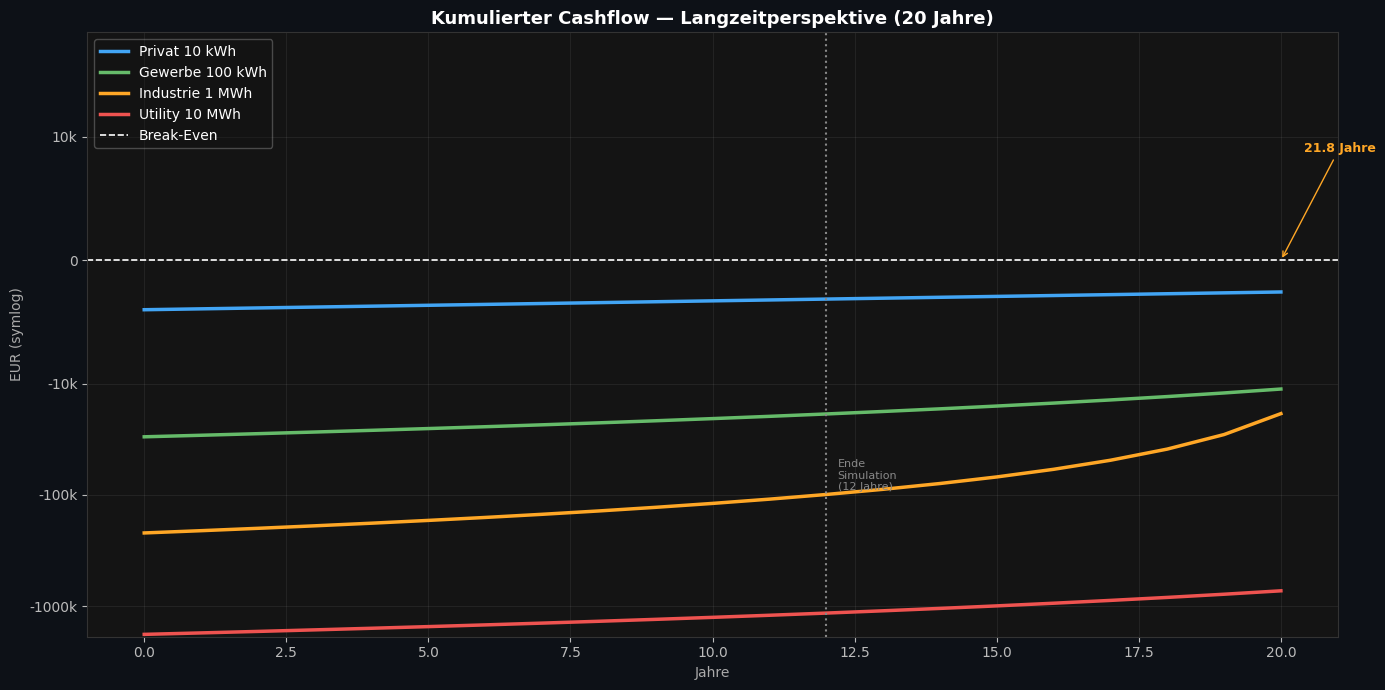

nb04_langzeit.png gespeichert


In [8]:
# ── Chart 1e: Langzeit-Amortisation (20 Jahre) ───────────────────────────────
# Zeigt alle Segmente bis Jahr 20, Marker bei Jahr 12 und Break-Even
# LIFETIME_LONG aus ../sync/config.json Setup-Zelle — nicht neu setzen

fig5, ax5 = plt.subplots(figsize=(14, 7))
fig5.patch.set_facecolor(BG_DARK)
ax5.set_facecolor(BG_PANEL)
ax5.tick_params(colors='#bbbbbb')
for sp in ax5.spines.values(): sp.set_edgecolor(C_SPINE)

years_long = np.arange(0, LIFETIME_LONG + 1)
for (segment, capex, net_annual), color in zip(
        zip(df_econ['segment'], df_econ['capex'], df_econ['net_annual']), SEG_COLORS):
    cf  = -capex + net_annual * years_long   # NumPy vector
    lbl = segment.replace('_',' ').replace('kWh',' kWh').replace('MWh',' MWh')
    ax5.plot(years_long, cf, color=color, lw=2.5, label=lbl)
    if net_annual > 0:
        be = capex / net_annual
        if be <= LIFETIME_LONG + 2:
            ax5.annotate(f'{be:.1f} Jahre',
                         xy=(min(be, LIFETIME_LONG), 0),
                         xytext=(min(be, LIFETIME_LONG) + 0.4, capex * 0.04),
                         color=color, fontsize=9, fontweight='bold',
                         arrowprops=dict(arrowstyle='->', color=color, lw=1.0))

# Break-Even Linie
ax5.axhline(0, color='white', lw=1.2, linestyle='--', label='Break-Even', zorder=2)

# Marker bei Jahr 12 (Ende Simulationszeitraum)
ax5.axvline(12, color=C_GRID, lw=1.5, linestyle=':', zorder=2)
ax5.text(12.2, ax5.get_ylim()[0] * 0.05 if ax5.get_ylim()[0] < 0 else ax5.get_ylim()[1] * 0.05,
         f'Ende\nSimulation\n({LIFETIME} Jahre)',
         color=C_GRID, fontsize=8, va='bottom')

# Symlog
ax5.set_yscale('symlog', linthresh=SYMLOG_THRESH)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v/1000:.0f}k' if abs(v) >= 1000 else f'{v:.0f}'))

ax5.set_title('Kumulierter Cashflow — Langzeitperspektive (20 Jahre)',
              color='white', fontsize=13, fontweight='bold')
ax5.set_xlabel('Jahre', color='#aaa')
ax5.set_ylabel('EUR (symlog)', color='#aaa')
ax5.legend(fontsize=10, framealpha=0.3, facecolor='#111', labelcolor='white')
ax5.grid(True, alpha=0.10)

plt.tight_layout()
p5 = os.path.join(CHARTS_DIR, 'nb04_langzeit.png')
plt.savefig(p5, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'nb04_langzeit.png gespeichert')

**Chart 1 — 4 Panels:**
- **Amortisation:** kumulierter Cashflow, Break-Even annotiert
- **ROI/Jahr:** direkter Vergleich mit 8.33%⚙-Ziel-Linie (= 100 / LIFETIME)
- **Erlös/kWh:** kapazitätsnormiert für Segmentvergleich
- **CAPEX vs. Netto-Erlös:** Investitionshöhe vs. 12 Jahre⚙-Ertrag

---
## 2. Heatmap – Spot-Preis nach Stunde × Monat <a id='chart-2-aufgabe-b-heatmap-spot-preis-nach-stunde-monat_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

*Karte/Heatmap gemäss Aufgabe b) – zeigt die zeitliche Preisstruktur als 2D-Heatmap.*  
Die Heatmap ist das zentrale Instrument zur Identifikation der optimalen Lade- und Einspeisezeitfenster.


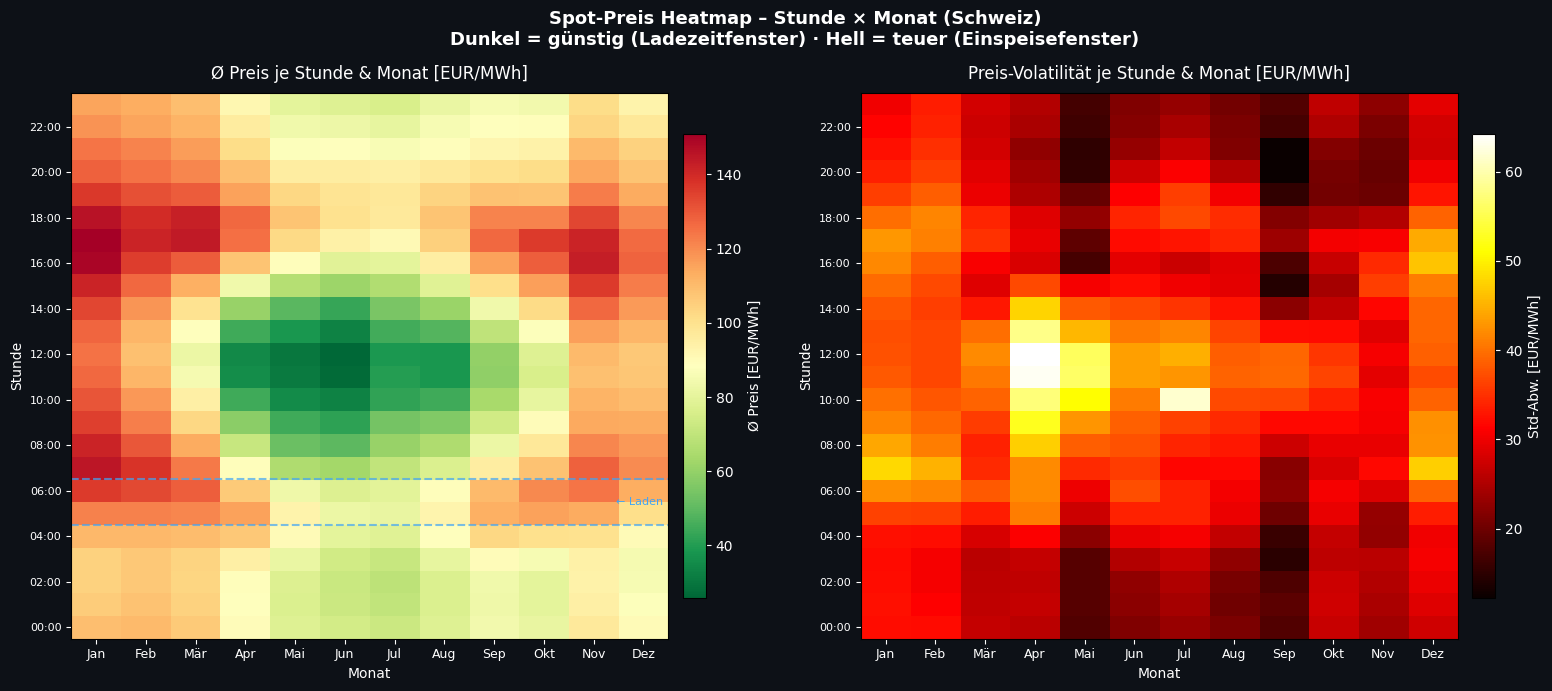

✅ Chart 2 gespeichert: ../output\charts\realistisch\nb04_heatmap_preis.png


In [9]:
# ── Chart 2: Heatmap Stunde × Monat (Aufgabe b) ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_DARK)
    ax.tick_params(colors='white')

fig.suptitle('Spot-Preis Heatmap – Stunde × Monat (Schweiz)\n'
             'Dunkel = günstig (Ladezeitfenster) · Hell = teuer (Einspeisefenster)',
             color='white', fontsize=13, fontweight='bold')

# Pivot-Tabelle: Mittelwert pro Stunde × Monat
pivot_both = df_prices.pivot_table(
    index='hour', columns='month', values='price_eur_mwh', aggfunc=['mean', 'std'])
pivot     = pivot_both['mean']
pivot_std_pre = pivot_both['std']

month_labels = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

# --- Panel 1: Heatmap Mittelwert ---
ax = axes[0]
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
               origin='lower', vmin=pivot.values.min(), vmax=pivot.values.max())
cbar = plt.colorbar(im, ax=ax, label='Ø Preis [EUR/MWh]', shrink=0.85, pad=0.02)
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, fontsize=9, color='white')
ax.set_yticks(range(24)[::2])
ax.set_yticklabels([f'{h:02d}:00' for h in range(24)[::2]], fontsize=8, color='white')
ax.set_title('Ø Preis je Stunde & Monat [EUR/MWh]', color='white', pad=10)
ax.set_xlabel('Monat', color='white')
ax.set_ylabel('Stunde', color='white')

# Günstigste Zone markieren (Laden)
ax.axhline(y=4.5, color='#42A5F5', lw=1.5, linestyle='--', alpha=0.7)
ax.axhline(y=6.5, color='#42A5F5', lw=1.5, linestyle='--', alpha=0.7)
ax.text(11.4, 5.5, '← Laden', color='#42A5F5', fontsize=8, ha='right', va='center')

# --- Panel 2: Heatmap Volatilität (Std) ---
pivot_std = pivot_std_pre  # bereits oben berechnet

ax2 = axes[1]
im2 = ax2.imshow(pivot_std.values, aspect='auto', cmap='hot',
                  origin='lower')
cbar2 = plt.colorbar(im2, ax=ax2, label='Std-Abw. [EUR/MWh]', shrink=0.85, pad=0.02)
cbar2.ax.yaxis.label.set_color('white')
cbar2.ax.tick_params(colors='white')

ax2.set_xticks(range(12))
ax2.set_xticklabels(month_labels, fontsize=9, color='white')
ax2.set_yticks(range(24)[::2])
ax2.set_yticklabels([f'{h:02d}:00' for h in range(24)[::2]], fontsize=8, color='white')
ax2.set_title('Preis-Volatilität je Stunde & Monat [EUR/MWh]', color='white', pad=10)
ax2.set_xlabel('Monat', color='white')
ax2.set_ylabel('Stunde', color='white')

plt.tight_layout()
chart2_path = os.path.join(CHARTS_DIR, 'nb04_heatmap_preis.png')
plt.savefig(chart2_path, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'✅ Chart 2 gespeichert: {chart2_path}')

**Einzelplot** (Preis-Heatmap):

In [10]:
# ── Chart 2: Einzelplots beider Panels ──────────────────────────────────────
# Panel A: Preis-Heatmap | Panel B: Volatilitäts-Heatmap — je eigenständig

pivot_both = df_prices.pivot_table(index='hour', columns='month',
                                    values='price_eur_mwh', aggfunc=['mean','std'])
pivot_mean = pivot_both['mean']
pivot_std  = pivot_both['std']
month_lbls = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

for pivot, cmap, fname, title, ctitle in [
    (pivot_mean, 'RdYlGn_r', 'nb04_heatmap_preis.png',
     'Ø Spot-Preis je Stunde & Monat [EUR/MWh]\nDunkel = günstig (Laden) · Hell = teuer (Einspeisen)',
     'Ø Preis [EUR/MWh]'),
    (pivot_std,  'hot_r',    'nb04_heatmap_volatilitaet.png',
     'Preis-Volatilität je Stunde & Monat [EUR/MWh]\nHell = hohe Volatilität (beste Spread-Chancen)',
     'Std-Abw. [EUR/MWh]'),
]:
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    fig2.patch.set_facecolor(BG_DARK)
    ax2.set_facecolor(BG_PANEL); ax2.tick_params(colors='#bbbbbb')
    for sp in ax2.spines.values(): sp.set_edgecolor(C_SPINE)
    im = ax2.imshow(pivot.values, cmap=cmap, aspect='auto',
                    origin='lower',
                    vmin=pivot.values.min(), vmax=pivot.values.max())
    cb = plt.colorbar(im, ax=ax2); cb.ax.tick_params(colors='white')
    cb.set_label(ctitle, color='white')
    ax2.set_xticks(range(12)); ax2.set_xticklabels(month_lbls, color='white')
    ax2.set_yticks(range(0,24,2))
    ax2.set_yticklabels([f'{h:02d}:00' for h in range(0,24,2)], color='white')
    ax2.set_title(title, color='white', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Monat', color='#aaa'); ax2.set_ylabel('Stunde', color='#aaa')
    # Ladezone-Marker nur für Preis-Heatmap (identisch Komposit)
    if 'preis' in fname:
        ax2.axhline(y=4.5, color='#42A5F5', lw=1.5, linestyle='--', alpha=0.7)
        ax2.axhline(y=6.5, color='#42A5F5', lw=1.5, linestyle='--', alpha=0.7)
        ax2.text(11.4, 5.5, '← Laden', color='#42A5F5', fontsize=9, ha='right', va='center')
    plt.tight_layout()
    p = os.path.join(CHARTS_DIR, fname)
    plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f'  Einzelplot: {fname}')

  Einzelplot: nb04_heatmap_preis.png
  Einzelplot: nb04_heatmap_volatilitaet.png


**Chart 2 (Heatmap) — Pflichtaufgabe b.**
Links: Ø Preis je Stunde×Monat — Solar-Mittagstief (grün) und Winter-Abend-Spitzen (dunkelrot) erkennbar.
Rechts: Preis-[Volatilität](../organisation/O_02_Glossar.ipynb#g-volatilitaet) — hohe Volatilität = grösseres Arbitrage-Potenzial.

---
## 3. Tagesprofil Netzlast & Spot-Preis <a id='chart-3-tagesprofil-netzlast-spot-preis_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Überlagerung von Netzlast und Preis über den Tagesverlauf. Markiert das optimale
Lade- (p25) und Einspeisefenster (p75) — visualisiert die [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch)-Logik direkt.


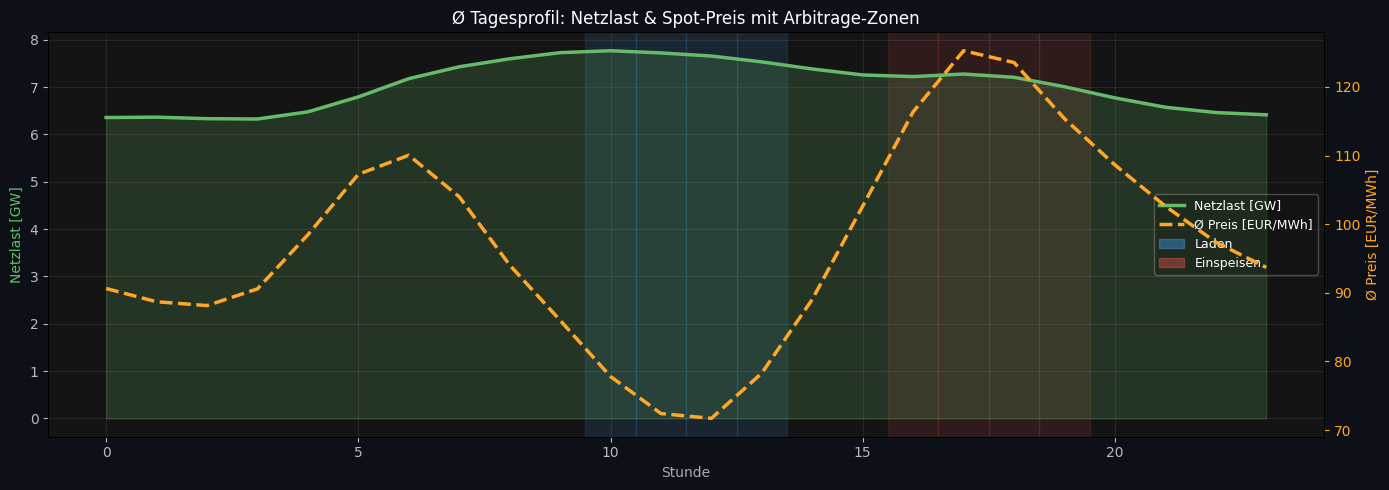

✅ Chart 3 gespeichert.


In [11]:
# ── Chart 3: Tagesprofil Netzlast & Preis ────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
for sp in ax.spines.values():
    sp.set_edgecolor(C_SPINE)

ax2 = ax.twinx()

# Stundenmittelwerte berechnen
# .dt.hour statt .hour weil der Index ein DatetimeIndex ist, keine Spalte
load_avg = df_load.copy()
load_avg['hour'] = load_avg['timestamp'].dt.hour
load_by_h  = load_avg.groupby('hour')['load_gw'].mean()
price_by_h = df_prices.groupby('hour')['price_eur_mwh'].mean()

ax.fill_between(load_by_h.index, load_by_h.values, alpha=0.2, color=C_LOAD)
ax.plot(load_by_h.index,   load_by_h.values,   color=C_LOAD,  lw=2.5, label='Netzlast [GW]')
ax2.plot(price_by_h.index, price_by_h.values,  color=C_PRICE, lw=2.5,
         linestyle='--', label='Ø Preis [EUR/MWh]')

# Günstigste und teuerste Stunden markieren
low_h  = price_by_h.nsmallest(4).index
high_h = price_by_h.nlargest(4).index
for h_val in low_h:
    ax.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.12, color='#42A5F5', zorder=0)
for h_val in high_h:
    ax.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.12, color='#EF5350', zorder=0)

ax.set_title('Ø Tagesprofil: Netzlast & Spot-Preis mit Arbitrage-Zonen',
             color='white', fontsize=12)
ax.set_xlabel('Stunde', color='#aaaaaa')
ax.set_ylabel('Netzlast [GW]', color=C_LOAD)
ax2.set_ylabel('Ø Preis [EUR/MWh]', color=C_PRICE)
ax.tick_params(colors='#bbbbbb')
ax2.tick_params(colors=C_PRICE)

p_blau = mpatches.Patch(color='#42A5F5', alpha=0.4, label='Ladezeitfenster (günstig)')
p_rot  = mpatches.Patch(color='#EF5350', alpha=0.4, label='Einspeisefenster (teuer)')
l1, n1 = ax.get_legend_handles_labels()
l2, n2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2 + [p_blau, p_rot], n1 + n2 + ['Laden', 'Einspeisen'],
          fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, alpha=0.12)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'nb04_tagesprofil.png'),
            dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print('✅ Chart 3 gespeichert.')

**Einzelplot** (grösseres Format):

In [12]:
# ── Chart 3: Einzelplot ───────────────────────────────────────────────────────
# Chart 3 ist bereits ein einzelner Chart → gleiche Logik wie Komposit, nur grösser
# KORREKTUR: Zonen-Logik wie im Komposit (nsmallest/nlargest 4 Stunden)
# Bug zuvor: p25.quantile(CHARGE_Q) = doppelter Quantil → fast keine Stunden qualifiziert
fig3, ax3 = plt.subplots(figsize=(14, 6))
fig3.patch.set_facecolor(BG_DARK)
ax3.set_facecolor(BG_PANEL); ax3.tick_params(colors='#bbbbbb')
for sp in ax3.spines.values(): sp.set_edgecolor(C_SPINE)
ax3b = ax3.twinx()
ax3b.tick_params(colors=C_PRICE)

h_load  = df_load.groupby(df_load['timestamp'].dt.hour)['load_gw'].mean()
h_price = df_prices.groupby('hour')['price_eur_mwh'].mean()

# Arbitrage-Zonen: 4 günstigste und 4 teuerste Stunden (identisch mit Komposit)
low_h  = h_price.nsmallest(4).index
high_h = h_price.nlargest(4).index
for h_val in low_h:
    ax3.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.18, color=C_CHARGE, zorder=0)
for h_val in high_h:
    ax3.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.18, color=C_FEED, zorder=0)

ax3.fill_between(h_load.index, h_load.values, alpha=0.15, color=C_LOAD)
ax3.plot(h_load.index, h_load.values, color=C_LOAD, lw=2.5, label='Netzlast [GW]')
ax3b.plot(h_price.index, h_price.values, color=C_PRICE, lw=2.5,
          linestyle='--', label='Ø Preis [EUR/MWh]')
ax3.set_xlabel('Stunde', color='#aaa')
ax3.set_ylabel('Netzlast [GW]', color=C_LOAD)
ax3b.set_ylabel('Ø Preis [EUR/MWh]', color=C_PRICE)
ax3.set_title('Ø Tagesprofil: Netzlast & Spot-Preis mit Arbitrage-Zonen',
              color='white', fontsize=13, fontweight='bold')
ax3.set_xticks(range(0, 24, 2))
ax3.set_xticklabels([f'{h}h' for h in range(0, 24, 2)])
ax3.grid(True, alpha=0.10)
l1, n1 = ax3.get_legend_handles_labels()
l2, n2 = ax3b.get_legend_handles_labels()
from matplotlib.patches import Patch
ax3.legend(
    l1 + l2 + [Patch(facecolor=C_CHARGE, alpha=0.5), Patch(facecolor=C_FEED, alpha=0.5)],
    n1 + n2 + ['Ladefenster', 'Einspeisefenster'],
    fontsize=10, framealpha=0.3, facecolor='#111', labelcolor='white', ncol=2)
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb04_tagesprofil_einzel.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.close()
print(f'  Einzelplot: nb04_tagesprofil_einzel.png')

  Einzelplot: nb04_tagesprofil_einzel.png


**Chart 3 — Tagesprofil.**
Blau = optimales Ladefenster (Preis unter p25), Rot = optimales Einspeisefenster (Preis über p75).
Zweite Y-Achse zeigt Preis in EUR/MWh.

---
## 4. Netzentlastungsszenarien <a id='chart-4-netzentlastungsszenarien_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Zeigt vier Rollout-Szenarien (Status Quo → Transformativ): wie stark aggregierte
Batterien die CH Spitzenlast (Basis: 10,5 GW) senken können.


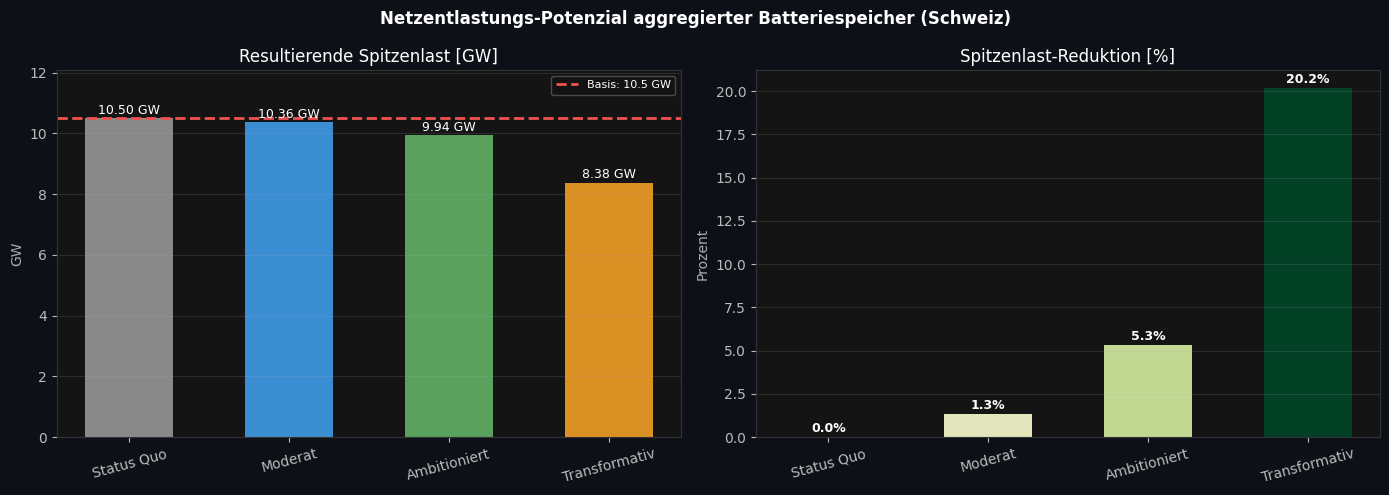

✅ Chart 4 gespeichert.


In [13]:
# ── Chart 4: Netzentlastungsszenarien ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors='#bbbbbb')
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
fig.suptitle('Netzentlastungs-Potenzial aggregierter Batteriespeicher (Schweiz)',
             color='white', fontsize=12, fontweight='bold')

BASE_PEAK = BASE_PEAK_GW  # aus ../sync/config.json (ch_spitzenlast_gw)
sc_names  = [s.split('(')[0].strip() for s in df_sc['szenario']]
sc_colors = [C_NO_DISP, C_PRIV, C_GEW, C_IND]   # SEG_COLORS[0–2] via Setup — SSOT: config.json

# Panel 1: Spitzenlast mit/ohne Batterien
ax = axes[0]
ax.axhline(BASE_PEAK, color=C_UTIL, lw=2, linestyle='--', label=f'Basis: {BASE_PEAK} GW')
bars = ax.bar(sc_names, df_sc['neue_spitzenlast_gw'], color=sc_colors, alpha=0.85, width=0.55)
for bar, row in zip(bars, df_sc.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{row.neue_spitzenlast_gw:.2f} GW', ha='center', va='bottom', color='white', fontsize=9)
ax.set_title('Resultierende Spitzenlast [GW]', color='white')
ax.set_ylabel('GW', color='#aaaaaa')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.set_ylim(0, BASE_PEAK * 1.15)
ax.grid(True, axis='y', alpha=0.15)

# Panel 2: Reduktion in %
ax = axes[1]
norm = Normalize(vmin=0, vmax=df_sc['reduktion_pct'].max())
cmap_fn = cm.get_cmap('YlGn')
colors_pct = [cmap_fn(norm(v)) for v in df_sc['reduktion_pct']]
bars2 = ax.bar(sc_names, df_sc['reduktion_pct'], color=colors_pct, alpha=0.9, width=0.55)
for bar, val in zip(bars2, df_sc['reduktion_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}%', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax.set_title('Spitzenlast-Reduktion [%]', color='white')
ax.set_ylabel('Prozent', color='#aaaaaa')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'nb04_netzentlastung.png'),dpi=DPI,bbox_inches='tight',facecolor=BG_DARK)
plt.show()
plt.close()
print('✅ Chart 4 gespeichert.')


**Einzelplots** (je Panel):

In [14]:
# ── Chart 4: Einzelplots ─────────────────────────────────────────────────────
for panel_idx, (filename, title) in enumerate([
    ('nb04_spitzenlast.png',    'Resultierende Spitzenlast [GW]'),
    ('nb04_spitzenlast_reduktion.png',  'Spitzenlast-Reduktion [%]'),
]):
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    fig4.patch.set_facecolor(BG_DARK)
    ax4.set_facecolor(BG_PANEL); ax4.tick_params(colors='#bbbbbb')
    for sp in ax4.spines.values(): sp.set_edgecolor(C_SPINE)
    sc_names_s = [s.split('(')[0].strip() for s in df_sc['szenario']]
    sc_colors_s = [C_NO_DISP, C_PRIV, C_GEW, C_IND]   # SEG_COLORS[0–2] via Setup — SSOT: config.json

    if panel_idx == 0:
        ax4.axhline(BASE_PEAK_GW, color=C_UTIL, lw=2, linestyle='--', label=f'Basis: {BASE_PEAK_GW} GW')
        bars = ax4.bar(sc_names_s, df_sc['neue_spitzenlast_gw'], color=sc_colors_s, alpha=0.85)
        for bar, val in zip(bars, df_sc['neue_spitzenlast_gw']):
            ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                     f'{val:.2f} GW', ha='center', color='white', fontsize=10, fontweight='bold')
        ax4.set_ylabel('GW', color='#aaa')
        ax4.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
    else:
        bars = ax4.bar(sc_names_s, df_sc['reduktion_pct'], color=sc_colors_s, alpha=0.85)
        for bar, val in zip(bars, df_sc['reduktion_pct']):
            ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f'{val:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Reduktion [%]', color='#aaa')

    ax4.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax4.grid(True, axis='y', alpha=0.12)
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, filename), dpi=DPI,
                bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f'  Einzelplot: {filename}')

  Einzelplot: nb04_spitzenlast.png
  Einzelplot: nb04_spitzenlast_reduktion.png


**Chart 4 — [Netzentlastung](../organisation/O_02_Glossar.ipynb#g-netzentlastung).**
Vier Rollout-Szenarien (Status Quo → Transformativ). Bei 800k Privatbatterien (Transformativ-Szenario 2035) und der aktiven Gleichzeitigkeitsannahme `realistisch` (40%⚙) resultiert eine Spitzenlast-Reduktion von ~20.2%📊.
Zum Vergleich: `pessimistisch` 15%⚙, `optimistisch` 70%⚙ (VPP-koordinierter [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch)).

---
## 5. Saisonale Arbitrage-Analyse <a id='saisonale-arbitrage-analyse_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Die folgenden Charts untersuchen, **wie stark die Rentabilität von [Grid-Arbitrage](../organisation/O_02_Glossar.ipynb#g-grid-arbitrage) von der Jahreszeit abhängt**.  
Grundlage: Mehrjährige Stundendaten aus `ch_spot_prices_clean.csv` und `ch_netzlast_raw.csv`.

**Kernthese:** Der Arbitrage-Spread (Differenz Hoch- zu Niedrigpreis) ist im **Frühling am grössten**, im Winter am kleinsten — entgegen der intuitiven Erwartung.  
Im Frühling treffen früher Solar-Mittagstief und noch hohe Heiz-Abendspitze aufeinander ([Duck Curve](../organisation/O_02_Glossar.ipynb#g-duck-curve)-Maximum), was die Tagesspanne auf ~84 EUR/MWh📊 treibt; im Winter bleibt das Profil flacher (~49 EUR/MWh📊).  
Dies hat direkte Auswirkungen auf die Standortwahl von Batterien (→ K_01 Räumliche Analyse).


---
### 5.1 Saisonale Analyse — Wann lohnt sich Arbitrage am meisten? <a id='chart-5-saisonale-analyse-wann-lohnt-sich-arbitrage-am-meisten_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Der **Arbitrage-Spread** variiert stark je nach Jahreszeit. Im Sommer drückt Solarproduktion
die Mittagspreise — der Spread ist kleiner. Im Winter ist die Last höher und die [Volatilität](../organisation/O_02_Glossar.ipynb#g-volatilitaet) grösser.
Chart 5a zeigt die Tagesprofile, Chart 5b quantifiziert den Unterschied monatlich.


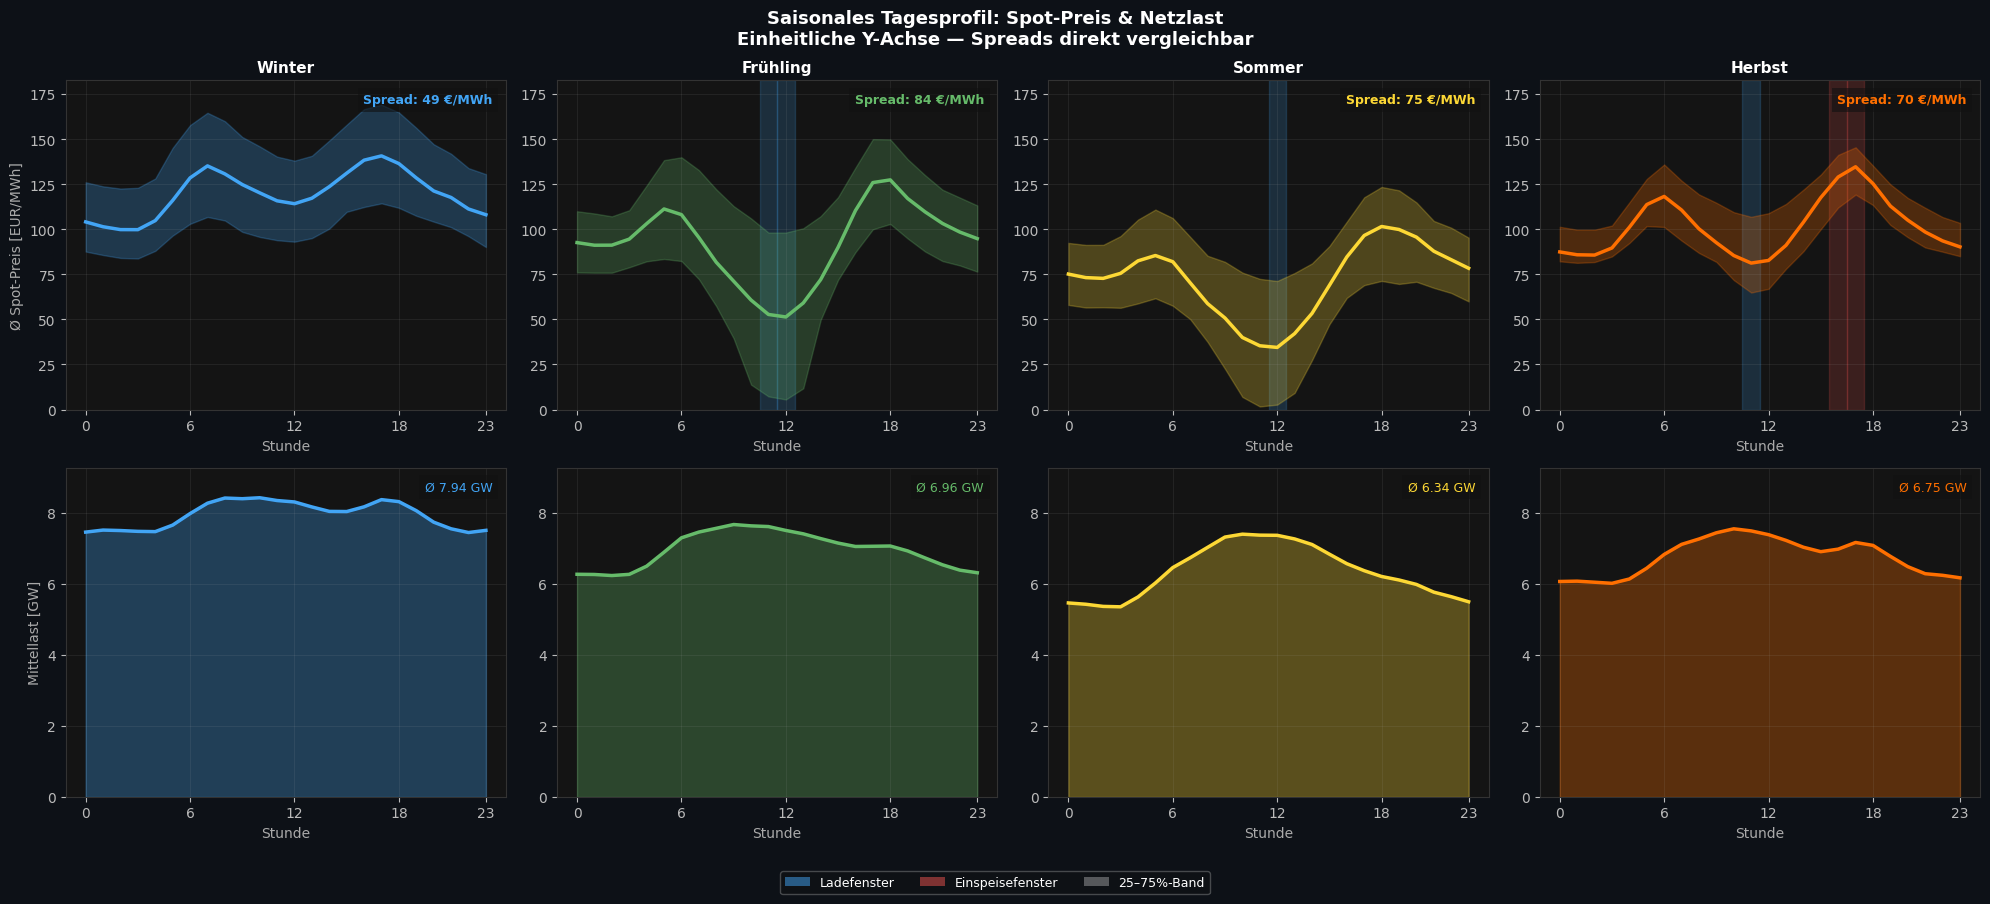

Chart 5a gespeichert: ../output\charts\realistisch\nb04_saisonal_tagesprofil.png
  Winter      : Spread    49 EUR/MWh | Negativpreise 0.2%
  Frühling    : Spread    84 EUR/MWh | Negativpreise 4.6%
  Sommer      : Spread    75 EUR/MWh | Negativpreise 4.7%
  Herbst      : Spread    70 EUR/MWh | Negativpreise 0.8%


In [15]:
# ── Chart 5a: Saisonales Tagesprofil Preis & Netzlast ────────────────────────
SAISON_MAP    = {0:'Winter',1:'Frühling',2:'Sommer',3:'Herbst'}
SAISON_MONATE = {0:[12,1,2],1:[3,4,5],2:[6,7,8],3:[9,10,11]}
# SAISON_COLORS: SSOT → config.json → visualisierung.farben.saison_colors (Setup Cell 6)

# ── Gemeinsame Y-Achsen-Grenzen vorab berechnen ──────────────────────────────
# Preis: einheitliche Y-Achse über alle Saisons — Saisonvergleich korrekt
# Last: ebenfalls einheitlich (Netzlast variiert saisonal, aber Skala bleibt lesbar)
all_p25, all_p75, all_load = [], [], []
for s_id in SAISON_MAP:
    monate = SAISON_MONATE[s_id]
    df_s = df_prices[df_prices['month'].isin(monate)]
    df_l = df_load[df_load['timestamp'].dt.month.isin(monate)]
    h_p  = df_s.groupby('hour')['price_eur_mwh'].agg(
               p25=lambda x: x.quantile(CHARGE_Q), p75=lambda x: x.quantile(DISCHARGE_Q))
    h_l  = df_l.groupby(df_l['timestamp'].dt.hour)['load_gw'].mean()
    all_p25.append(h_p['p25'].min())
    all_p75.append(h_p['p75'].max())
    all_load.append(h_l.max())

price_ymin = min(all_p25) * 1.05 if min(all_p25) < 0 else max(0, min(all_p25) - 10)
price_ymax = max(all_p75) * 1.08
load_ymin  = 0
load_ymax  = max(all_load) * 1.10

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Saisonales Tagesprofil: Spot-Preis & Netzlast\n'
             'Einheitliche Y-Achse — Spreads direkt vergleichbar',
             color='white', fontsize=13, fontweight='bold')

for col, (s_id, s_name) in enumerate(SAISON_MAP.items()):
    monate = SAISON_MONATE[s_id]
    df_s   = df_prices[df_prices['month'].isin(monate)]
    df_l   = df_load[df_load['timestamp'].dt.month.isin(monate)]
    h_p    = df_s.groupby('hour')['price_eur_mwh'].agg(['mean','std',
              lambda x:x.quantile(CHARGE_Q), lambda x:x.quantile(DISCHARGE_Q)])
    h_p.columns = ['mean','std','p25','p75']
    h_l    = df_l.groupby(df_l['timestamp'].dt.hour)['load_gw'].mean()
    # Saisonaler Marktpreisspread (Tages-max-min Mittel) aus transfer.json (NB03 SSOT)
    spread = TF_SAISONAL.get(s_name, {}).get('spread_max_min_eur_mwh')
    if spread is None:
        raise RuntimeError(f"saisonal.{s_name}.spread_max_min_eur_mwh fehlt in transfer.json — NB03 ausführen")
    col_s  = SAISON_COLORS.get(s_name, '#888888')

    for row_idx, (ax, ylabel) in enumerate([
        (axes[0,col], 'EUR/MWh'),
        (axes[1,col], 'GW'),
    ]):
        ax.set_facecolor(BG_PANEL); ax.tick_params(colors='#bbbbbb')
        for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
        if row_idx == 0:
            ax.fill_between(h_p.index, h_p['p25'], h_p['p75'], alpha=0.25, color=col_s)
            ax.plot(h_p.index, h_p['mean'], color=col_s, lw=2.5)
            lo_t = h_p['p25'].quantile(CHARGE_Q); hi_t = h_p['p75'].quantile(DISCHARGE_Q)
            for h_val in h_p.index:
                if h_p.loc[h_val,'mean'] <= lo_t:
                    ax.axvspan(h_val-.5, h_val+.5, alpha=0.18, color=SAISON_COLORS.get('Winter', C_PRIV), zorder=0)
                elif h_p.loc[h_val,'mean'] >= hi_t:
                    ax.axvspan(h_val-.5, h_val+.5, alpha=0.18, color=C_UTIL, zorder=0)
            ax.set_ylim(price_ymin, price_ymax)  # ← einheitlich
            ax.set_title(s_name, color='white', fontsize=11, fontweight='bold')
            ax.text(0.97, 0.96, f'Spread: {spread:.0f} €/MWh',
                    transform=ax.transAxes, ha='right', va='top', color=col_s,
                    fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='#111', alpha=0.6, edgecolor='none'))
        else:
            ax.fill_between(h_l.index, h_l.values, alpha=0.3, color=col_s)
            ax.plot(h_l.index, h_l.values, color=col_s, lw=2.5)
            ax.set_ylim(load_ymin, load_ymax)  # ← einheitlich
            ax.text(0.97, 0.96, f'Ø {h_l.mean():.2f} GW',
                    transform=ax.transAxes, ha='right', va='top', color=col_s, fontsize=9,
                    bbox=dict(facecolor='#111', alpha=0.6, edgecolor='none'))
        ax.set_xlabel('Stunde', color='#aaa'); ax.set_xticks([0,6,12,18,23]); ax.grid(True, alpha=0.10)
        if col == 0: ax.set_ylabel(ylabel, color='#aaa')

axes[0,0].set_ylabel('Ø Spot-Preis [EUR/MWh]', color='#aaa')
axes[1,0].set_ylabel('Mittellast [GW]', color='#aaa')

from matplotlib.patches import Patch
fig.legend([Patch(facecolor=SAISON_COLORS.get('Winter',C_PRIV),alpha=0.5),
            Patch(facecolor=C_UTIL,alpha=0.5),
            Patch(facecolor='white',alpha=0.3)],
           ['Ladefenster','Einspeisefenster','25–75%-Band'],
           loc='lower center', ncol=3, fontsize=9, framealpha=0.3, facecolor='#111',
           labelcolor='white', bbox_to_anchor=(0.5,-0.01))
plt.tight_layout(rect=[0,0.04,1,1])
p = os.path.join(CHARTS_DIR,'nb04_saisonal_tagesprofil.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Chart 5a gespeichert: {p}')
for s_id, s_name in SAISON_MAP.items():
    df_s = df_prices[df_prices['month'].isin(SAISON_MONATE[s_id])]
    sp   = TF_SAISONAL.get(s_name, {}).get('spread_max_min_eur_mwh', 0)
    neg  = (df_s['price_eur_mwh']<0).mean()*100
    print(f'  {s_name:<12}: Spread {sp:>5.0f} EUR/MWh | Negativpreise {neg:.1f}%')

**Einzelplots** (Winter + Sommer für Bericht):

In [16]:
# ── Chart 5a: Einzelplots alle 4 Saisons — gleiche Y-Achse wie Gesamtchart ──
# price_ymin / price_ymax / load_ymin / load_ymax aus vorheriger Zelle verfügbar
for saison_key, saison_name in SAISON_MAP.items():
    monate = SAISON_MONATE[saison_key]
    df_s   = df_prices[df_prices['month'].isin(monate)]
    df_l   = df_load[df_load['timestamp'].dt.month.isin(monate)]
    h_p    = df_s.groupby('hour')['price_eur_mwh'].agg(['mean',
              lambda x: x.quantile(CHARGE_Q), lambda x: x.quantile(DISCHARGE_Q)])
    h_p.columns = ['mean','p25','p75']
    h_l    = df_l.groupby(df_l['timestamp'].dt.hour)['load_gw'].mean()
    # Saisonaler Marktpreisspread aus transfer.json (NB03 SSOT)
    spread = TF_SAISONAL.get(saison_name, {}).get('spread_max_min_eur_mwh')
    if spread is None:
        raise RuntimeError(f"saisonal.{saison_name}.spread_max_min_eur_mwh fehlt in transfer.json — NB03 ausführen")
    col_s  = SAISON_COLORS[saison_name]

    fig5, (ax5a, ax5b) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
    fig5.patch.set_facecolor(BG_DARK)
    fig5.suptitle(f'Tagesprofil {saison_name}: Spot-Preis & Netzlast\n'
                  f'Arbitrage-Spread: {spread:.0f} EUR/MWh',
                  color='white', fontsize=14, fontweight='bold')
    for ax5 in [ax5a, ax5b]:
        ax5.set_facecolor(BG_PANEL); ax5.tick_params(colors='#bbbbbb')
        for sp in ax5.spines.values(): sp.set_edgecolor(C_SPINE)
        ax5.grid(True, alpha=0.10)

    ax5a.fill_between(h_p.index, h_p['p25'], h_p['p75'], alpha=0.25, color=col_s)
    ax5a.plot(h_p.index, h_p['mean'], color=col_s, lw=2.5)
    lo_t = h_p['p25'].quantile(CHARGE_Q); hi_t = h_p['p75'].quantile(DISCHARGE_Q)
    for h_val in h_p.index:
        if h_p.loc[h_val,'mean'] <= lo_t:
            ax5a.axvspan(h_val-.5, h_val+.5, alpha=0.20, color=C_CHARGE, zorder=0)
        elif h_p.loc[h_val,'mean'] >= hi_t:
            ax5a.axvspan(h_val-.5, h_val+.5, alpha=0.20, color=C_FEED, zorder=0)
    ax5a.set_ylim(price_ymin, price_ymax)
    ax5a.set_ylabel('EUR/MWh', color='#aaa')
    ax5a.set_title('Ø Spot-Preis mit 25-75% Band', color='white')

    ax5b.fill_between(h_l.index, h_l.values, alpha=0.30, color=col_s)
    ax5b.plot(h_l.index, h_l.values, color=col_s, lw=2.5)
    ax5b.set_ylim(load_ymin, load_ymax)
    ax5b.set_ylabel('Mittellast [GW]', color='#aaa')
    ax5b.set_xlabel('Stunde', color='#aaa')
    ax5b.set_title('Ø Netzlast', color='white')
    ax5b.set_xticks(range(0,24,2))
    ax5b.set_xticklabels([f'{h}h' for h in range(0,24,2)])


    from matplotlib.patches import Patch
    fig5.legend(
        [Patch(facecolor=C_CHARGE, alpha=0.5), Patch(facecolor=C_FEED, alpha=0.5)],
        ['Ladefenster', 'Einspeisefenster'],
        loc='lower center', ncol=2, fontsize=9, framealpha=0.3,
        facecolor='#111', labelcolor='white', bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    fname = f'nb04_saisonal_{saison_name.lower()}.png'
    plt.savefig(os.path.join(CHARTS_DIR, fname), dpi=DPI,
                bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f'  Einzelplot: {fname}')

  Einzelplot: nb04_saisonal_winter.png
  Einzelplot: nb04_saisonal_frühling.png
  Einzelplot: nb04_saisonal_sommer.png
  Einzelplot: nb04_saisonal_herbst.png


**Kernergebnis Chart 5a:** Der **Tages-Spread** (Tageshoch − Tagestief, Saison-Mittel) ist im **Frühling am höchsten** (~84 EUR/MWh📊), gefolgt von Sommer (~75), Herbst (~70) und Winter (~49). Die einheitliche Y-Achse macht den saisonalen Unterschied direkt sichtbar.
Die blauen/roten Hintergrundbänder verschieben sich saisonal: Im Sommer liegt das Ladefenster tagsüber (Solar-Mittagstief), im Winter nachts.


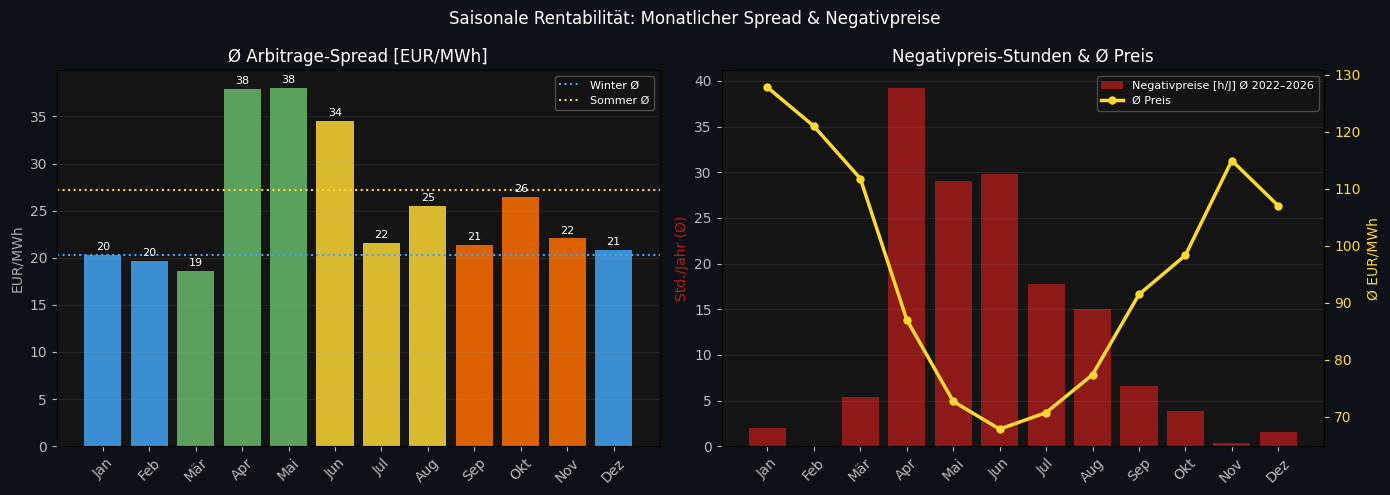

Chart 5b: ../output\charts\realistisch\nb04_saisonal_roi.png
Modus: durchschnitt | Jahre: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)] (5J)
Winter Ø 20 / Sommer Ø 27 EUR/MWh
  Einzelplot: nb04_spread_monatlich.png
  Einzelplot: nb04_negativpreise.png


In [17]:
# ── Chart 5b: Monatlicher Spread & Dispatch-Stunden ──────────────────────────
# ── Parameter ─────────────────────────────────────────────────────────────────
NEG_H_MODUS = 'durchschnitt'   # 'durchschnitt' = Ø pro Jahr | 'sum' = Total über alle Jahre
                                # | 'jahr' = spezifisches Jahr (NEG_H_JAHR setzen)
NEG_H_JAHR  = 2024              # Nur relevant wenn NEG_H_MODUS = 'jahr'
# ──────────────────────────────────────────────────────────────────────────────

months_all  = range(1,13)
month_names = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

# Datenzeitraum für Ø-Berechnung
_years_all = sorted(df_prices['timestamp'].dt.year.unique())
_n_years   = len(_years_all)

monthly_stats = []
for m in months_all:
    df_m = df_prices[df_prices['month'] == m]
    h_p  = df_m.groupby('hour')['price_eur_mwh'].mean()
    sp   = h_p.quantile(DISCHARGE_Q) - h_p.quantile(CHARGE_Q)

    if NEG_H_MODUS == 'durchschnitt':
        neg_h = (df_m['price_eur_mwh'] < 0).sum() / _n_years   # Ø pro Jahr
    elif NEG_H_MODUS == 'jahr':
        df_year = df_m[df_m['timestamp'].dt.year == NEG_H_JAHR]
        neg_h   = (df_year['price_eur_mwh'] < 0).sum()
    else:  # 'sum'
        neg_h = (df_m['price_eur_mwh'] < 0).sum()

    monthly_stats.append({
        'month': m, 'spread': sp, 'neg_hours': neg_h,
        'mean_price': df_m['price_eur_mwh'].mean()
    })
df_mon = pd.DataFrame(monthly_stats)

# Achsentitel je nach Modus
if NEG_H_MODUS == 'durchschnitt':
    _neg_lbl = f'Negativpreise [h/J] Ø {_years_all[0]}–{_years_all[-1]}'
    _neg_ylabel = 'Std./Jahr (Ø)'
elif NEG_H_MODUS == 'jahr':
    _neg_lbl = f'Negativpreise [h] {NEG_H_JAHR}'
    _neg_ylabel = f'Stunden {NEG_H_JAHR}'
else:
    _neg_lbl = f'Negativpreise [h] Total {_years_all[0]}–{_years_all[-1]}'
    _neg_ylabel = 'Stunden total'

scols = [(SAISON_COLORS.get('Winter',   C_PRIV)    if m in [12,1,2] else
          SAISON_COLORS.get('Frühling', C_GEW)     if m in [3,4,5]  else
          SAISON_COLORS.get('Sommer',   C_SOLAR)   if m in [6,7,8]  else
          SAISON_COLORS.get('Herbst',   C_GRENZWERT)) for m in months_all]
winter_mean = df_mon[df_mon['month'].isin([12,1,2])]['spread'].mean()
sommer_mean = df_mon[df_mon['month'].isin([6,7,8])]['spread'].mean()

# ── Gesamtchart ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
for ax in axes: ax.set_facecolor(BG_PANEL); ax.tick_params(colors='#bbbbbb')
fig.suptitle('Saisonale Rentabilität: Monatlicher Spread & Negativpreise', color='white', fontsize=12)

ax = axes[0]
bars = ax.bar(month_names, df_mon['spread'], color=scols, alpha=0.85)
ax.axhline(winter_mean, color=SAISON_COLORS.get('Winter',C_PRIV), lw=1.5, linestyle=':', label='Winter Ø')
ax.axhline(sommer_mean, color=SAISON_COLORS.get('Sommer',C_SOLAR), lw=1.5, linestyle=':', label='Sommer Ø')
for bar, val in zip(bars, df_mon['spread']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.0f}',
            ha='center', va='bottom', color='white', fontsize=8)
ax.set_title('Ø Arbitrage-Spread [EUR/MWh]', color='white')
ax.set_ylabel('EUR/MWh', color='#aaa')
ax.tick_params(axis='x', rotation=45); ax.grid(True, axis='y', alpha=0.12)
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')

ax = axes[1]; ax2 = ax.twinx()
ax.bar(month_names, df_mon['neg_hours'], color=C_FEED, alpha=0.75, label=_neg_lbl)
ax2.plot(month_names, df_mon['mean_price'], color=C_SOLAR, lw=2.5, marker='o', markersize=5, label='Ø Preis')
ax.set_title('Negativpreis-Stunden & Ø Preis', color='white')
ax.set_ylabel(_neg_ylabel, color=C_FEED); ax2.set_ylabel('Ø EUR/MWh', color=C_SOLAR)
ax.tick_params(axis='x', rotation=45); ax2.tick_params(colors=C_SOLAR)
ax.grid(True, axis='y', alpha=0.12)
l1, n1 = ax.get_legend_handles_labels(); l2, n2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, n1+n2, fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb04_saisonal_roi.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close(); print(f'Chart 5b: {p}')
print(f'Modus: {NEG_H_MODUS} | Jahre: {_years_all} ({_n_years}J)')
print(f'Winter Ø {winter_mean:.0f} / Sommer Ø {sommer_mean:.0f} EUR/MWh')

# ── Einzelplot 1: Spread ──────────────────────────────────────────────────────
fig_s, ax_s = plt.subplots(figsize=(11, 5))
fig_s.patch.set_facecolor(BG_DARK); ax_s.set_facecolor(BG_PANEL)
ax_s.tick_params(colors='#bbbbbb')
for sp in ax_s.spines.values(): sp.set_edgecolor(C_SPINE)
bars_s = ax_s.bar(month_names, df_mon['spread'], color=scols, alpha=0.85)
ax_s.axhline(winter_mean, color=SAISON_COLORS.get('Winter',C_PRIV), lw=1.5, linestyle=':',
             label=f'Winter Ø ({winter_mean:.0f} EUR/MWh)')
ax_s.axhline(sommer_mean, color=SAISON_COLORS.get('Sommer',C_SOLAR), lw=1.5, linestyle=':',
             label=f'Sommer Ø ({sommer_mean:.0f} EUR/MWh)')
for bar, val in zip(bars_s, df_mon['spread']):
    ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.0f}',
              ha='center', va='bottom', color='white', fontsize=9)
ax_s.set_title('Ø Arbitrage-Spread [EUR/MWh]', color='white', fontsize=13)
ax_s.set_ylabel('EUR/MWh', color='#aaa')
ax_s.tick_params(axis='x', rotation=45); ax_s.grid(True, axis='y', alpha=0.12)
ax_s.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'nb04_spread_monatlich.png'),
            dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.close(); print('  Einzelplot: nb04_spread_monatlich.png')

# ── Einzelplot 2: Negativpreise + Ø Preis ────────────────────────────────────
fig_n, ax_n = plt.subplots(figsize=(11, 5))
fig_n.patch.set_facecolor(BG_DARK); ax_n.set_facecolor(BG_PANEL)
ax_n.tick_params(colors='#bbbbbb')
for sp in ax_n.spines.values(): sp.set_edgecolor(C_SPINE)
ax_n2 = ax_n.twinx()
ax_n.bar(month_names, df_mon['neg_hours'], color=C_FEED, alpha=0.75, label=_neg_lbl)
ax_n2.plot(month_names, df_mon['mean_price'], color=C_SOLAR, lw=2.5,
           marker='o', markersize=5, label='Ø Preis')
ax_n.set_title('Negativpreis-Stunden & Ø Preis', color='white', fontsize=13)
ax_n.set_ylabel(_neg_ylabel, color=C_FEED)
ax_n2.set_ylabel('Ø EUR/MWh', color=C_SOLAR)
ax_n.tick_params(axis='x', rotation=45); ax_n2.tick_params(colors=C_SOLAR)
ax_n.grid(True, axis='y', alpha=0.12)
l1, n1 = ax_n.get_legend_handles_labels(); l2, n2 = ax_n2.get_legend_handles_labels()
ax_n.legend(l1+l2, n1+n2, fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'nb04_negativpreise.png'),
            dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.close(); print('  Einzelplot: nb04_negativpreise.png')

**Fazit Chart 5b:** Frühling (grün) und Sommer (gelb) liegen beim monatlichen p75−p25-Spread eng beieinander, mit einem Maximum im **Mai (~38 EUR/MWh📊)**. Negativpreise treten in beiden Saisons in vergleichbarer Häufigkeit auf (~4.5–4.7%📊) — beide Jahreszeiten bieten dadurch zusätzliche kostenlose Ladezyklen.

---
## Fazit <a id='fazit_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Alle Pflicht-Charts erzeugt und in `output/charts/` abgelegt. Kernaussagen aus
den Visualisierungen:

- **Arbitrage-Potenzial** ist stark segmentabhängig — bei reiner Arbitrage erreicht
  **kein Segment** den Break-Even innerhalb der angenommenen Lifetime von 12⚙ Jahren
  (Industrie kommt mit ~21.9 Jahren📊 am nächsten)
- **Tageszeit-Muster** — Lade-Fenster typisch 02:00–05:00,
  Entlade-Fenster 18:00–21:00 (Abendspitze)
- **Saisonale Verschiebung** — Frühling bietet den höchsten Spread,
  Winter den niedrigsten; Sommer hat zeitweise Negativpreise (Solar-Mittagstief)
- **Netzentlastung** — Rollout skaliert linear mit Gleichzeitigkeitsrate;
  bei hoher Koordination deutlicher Effekt auf Spitzenlast

Diese Charts bilden die Grundlage für die strategischen Empfehlungen
in `NB00` (Business Case) und werden in mehreren Kür-Notebooks referenziert.


---
## Abschluss <a id='abschluss_NB_04'></a>

[↑ Inhaltsverzeichnis](#toc_NB_04)

Alle Pflicht-Charts auf Existenz prüfen. Fehlende Charts: NB03 erneut ausführen.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `final_check` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar.


In [18]:
show_source(final_check)

<details>
<summary>🔎 Quellcode: <code>final_check</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def final_check(nb_label, files=None, *, weiter_msg=None, fehler_msg=None,
                extras=None, show_dataindex=False,
                dataindex_path='../sync/dataindex.csv', width=60):
    """Standardisierte End-of-Notebook-Kontrolle für Pflicht- und Kür-NBs.

    Prüft Existenz und Mindestgrösse der angegebenen Output-Dateien,
    gibt formatiertes Resultat aus und liefert ``all_ok`` als Bool zurück.

    Parameter
    ---------
    nb_label : str
        Label des Notebooks im Output-Header, z.B. ``"NB01"``, ``"K_03"``.
    files : list of tuple, optional
        Zu prüfende Dateien als ``(path, label, min_bytes)``-Tuples.

        * ``min_bytes = 0`` → nur Existenz prüfen, Grösse nicht ausgeben
          (z.B. für PNG-Charts).
        * ``min_bytes > 0`` → zusätzlich Grösse prüfen und in KB/MB ausgeben
          (z.B. für CSV-Dateien).

        Bei ``files=None`` oder ``files=[]`` wird kein Check ausgeführt;
        die Funktion dient dann als reiner Status-Print (für Report-NBs
        ohne eigene Outputs wie K_00).
    weiter_msg : str, optional
        Nachricht für den Erfolgsfall, z.B. ``"NB02 Daten Bereinigung"``.
        Default: ``"nächstes Notebook"``.
    fehler_msg : str, optional
        Nachricht für den Fehlerfall (Kurzform, ohne "Fehler beheben vor").
        Default: identisch mit ``weiter_msg``.
    extras : list of str, optional
        Zusätzliche Print-Zeilen zwischen Datei-Check und Weiter-/Fehler-Hinweis.
        Sinnvoll für Kür-Hinweise oder Kontext.
    show_dataindex : bool, default False
        Wenn True, wird der aktive Auszug aus ``../sync/dataindex.csv`` ausgegeben.
        Typisch für NB01.
    dataindex_path : str, default '../sync/dataindex.csv'
        Pfad zur dataindex.csv (für ``show_dataindex=True``).
    width : int, default 60
        Breite der Trennlinie aus ``=``-Zeichen.

    Return
    ------
    bool
        ``True`` wenn alle Files existieren und Mindestgrösse erfüllen,
        ``False`` sonst. Bei ``files=None``/leer immer ``True``.
    """
    print(f'{nb_label} – Abschlusskontrolle')
    print('=' * width)

    all_ok = True

    if files:
        for path, label, min_bytes in files:
            exists = os.path.exists(path)
            size = os.path.getsize(path) if exists else 0
            ok = exists and size >= min_bytes

            if min_bytes > 0:
                size_str = _format_size(size) if exists else '   FEHLT'
                print(f'  {"✅" if ok else "❌"}  {label:<45} {size_str}')
            else:
                print(f'  {"✅" if ok else "❌"}  {label}')

            if not ok:
                all_ok = False

    if extras:
        if files:
            print()
        for line in extras:
            print(line)

    if show_dataindex and os.path.exists(dataindex_path):
        import pandas as pd
        df_idx = pd.read_csv(dataindex_path)
        active = df_idx[df_idx['status'] == 'active']
        print(f'\ndataindex.csv: {len(df_idx)} Einträge total, {len(active)} active')
        print(active[['filename', 'data_type', 'rows', 'size_kb', 'timestamp']]
              .to_string(index=False))

    print()
    weiter = weiter_msg or 'nächstes Notebook'
    fehler = fehler_msg or weiter
    if all_ok:
        print(f'→ Weiter mit {weiter}.')
    else:
        print(f'→ Fehler beheben vor {fehler}.')

    return all_ok
```

</details>


In [19]:
# ── Abschlusskontrolle NB04 ──────────────────────────────────────────────────
_expected_charts = [
    'nb04_wirtschaftlichkeit.png', 'nb04_amortisation.png',
    'nb04_roi.png', 'nb04_erloese_kwh.png', 'nb04_langzeit.png',
    'nb04_heatmap_preis.png', 'nb04_tagesprofil.png',
    'nb04_netzentlastung.png', 'nb04_saisonal_tagesprofil.png',
    'nb04_saisonal_roi.png', 'nb04_spread_monatlich.png',
    'nb04_negativpreise.png',
]
final_check(
    'NB04',
    files=[(os.path.join(CHARTS_DIR, fname), fname, 0) for fname in _expected_charts],
    weiter_msg='NB00 Business Case',
    fehler_msg='NB00',
)

NB04 – Abschlusskontrolle
  ✅  nb04_wirtschaftlichkeit.png
  ✅  nb04_amortisation.png
  ✅  nb04_roi.png
  ✅  nb04_erloese_kwh.png
  ✅  nb04_langzeit.png
  ✅  nb04_heatmap_preis.png
  ✅  nb04_tagesprofil.png
  ✅  nb04_netzentlastung.png
  ✅  nb04_saisonal_tagesprofil.png
  ✅  nb04_saisonal_roi.png
  ✅  nb04_spread_monatlich.png
  ✅  nb04_negativpreise.png

→ Weiter mit NB00 Business Case.


True

| [← NB03 Daten Analyse](03_Daten_Analyse.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [NB00 Business Case →](00_Business_Case.ipynb) |
|:---|:---:|---:|